<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"


### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [3]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [5]:
import pandas as pd

def main():
    # Prompt for CSV path
    csv_path = "dataset.csv"
    if not csv_path:
        print("No file path provided. Exiting.")
        return

    # Load the data with headers in the first row
    df = pd.read_csv(csv_path, header=0)
    print("\nLoaded dataset with shape:", df.shape)

    # Show basic information
    print("\nData types:")
    print(df.dtypes)

    print("\nFirst few rows (optional):")
    print(df.head())

    # Generate descriptive statistics for all features (including objects)
    print("\nStatistical description (include='all'):")
    desc_all = df.describe(include='all')
    print(desc_all.to_string())

    # Optional: save the statistics to a file
    save_choice = 'y'
    if save_choice == 'y':
        with open('dataset_description.txt', 'w', encoding='utf-8') as f:
            f.write("Dataset shape: {}\n\n".format(df.shape))
            f.write("Data types:\n")
            f.write(str(df.dtypes) + "\n\n")
            f.write("Statistical description (include='all'):\n")
            f.write(desc_all.to_string())
        print("Statistics saved to dataset_description.txt")

if __name__ == "__main__":
    main()


Loaded dataset with shape: (238, 16)

Data types:
Unnamed: 0.1          int64
Unnamed: 0            int64
Manufacturer         object
Category              int64
GPU                   int64
OS                    int64
CPU_core              int64
Screen_Size_inch    float64
CPU_frequency       float64
RAM_GB                int64
Storage_GB_SSD        int64
Weight_pounds       float64
Price                 int64
Price-binned         object
Screen-Full_HD        int64
Screen-IPS_panel      int64
dtype: object

First few rows (optional):
   Unnamed: 0.1  Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  \
0             0           0         Acer         4    2   1         5   
1             1           1         Dell         3    1   1         3   
2             2           2         Dell         3    1   1         7   
3             3           3         Dell         4    2   1         5   
4             4           4           HP         4    2   1         7   

   Screen_Size_inch 

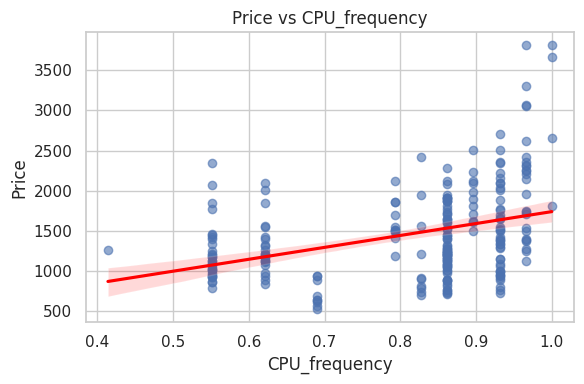

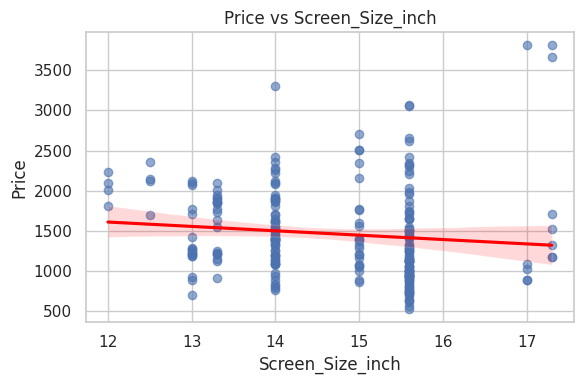

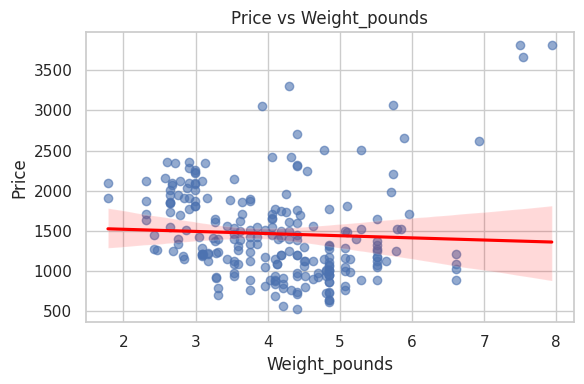

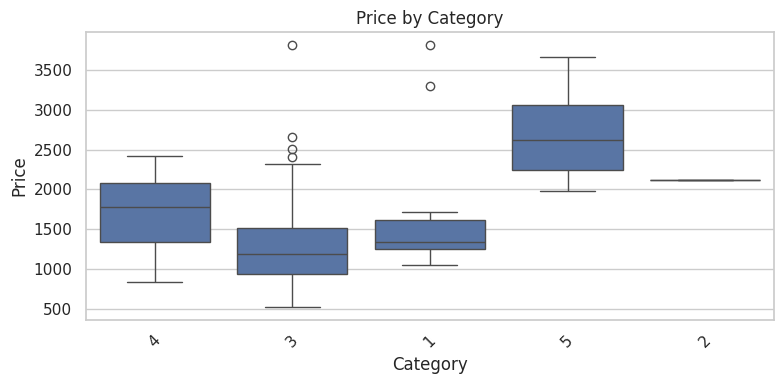

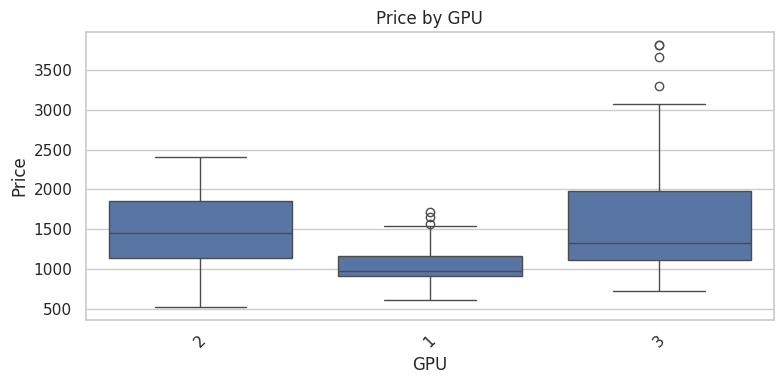

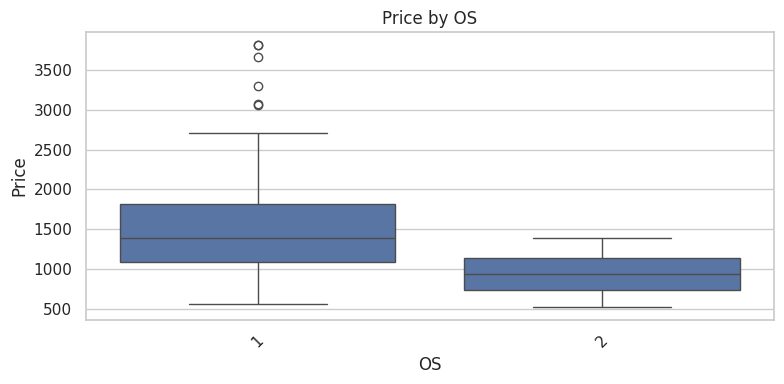

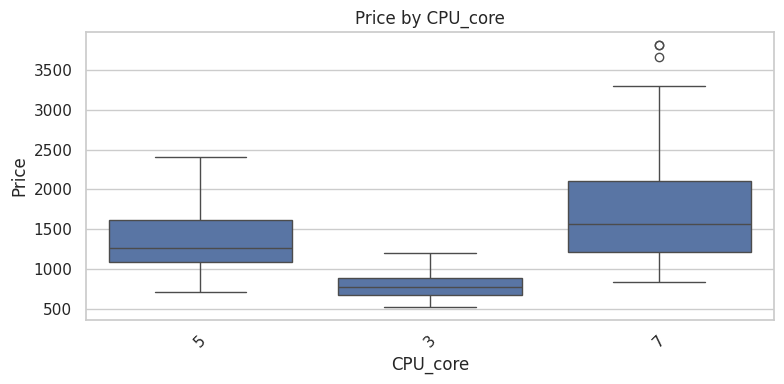

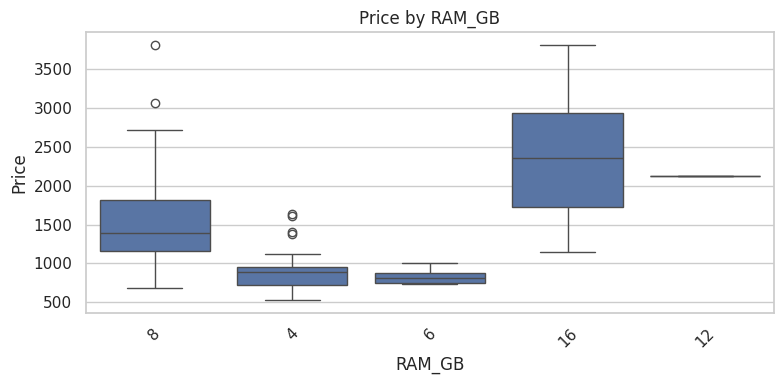

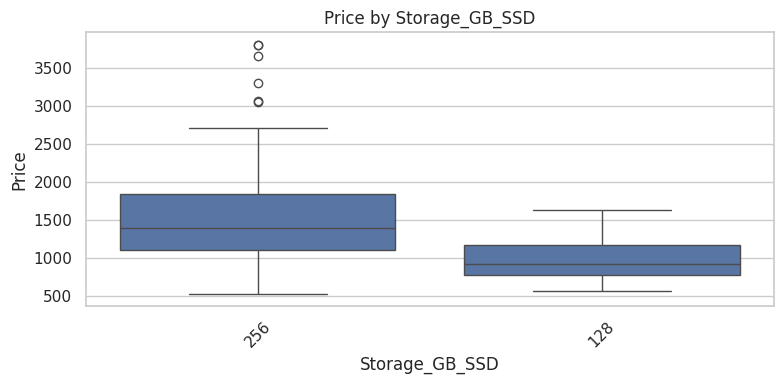

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: improve visuals
sns.set(style="whitegrid")

df = pd.read_csv('dataset.csv')
# If you already have df in memory, skip the above and proceed.

# Ensure required columns exist
required = [
    'Price',
    'CPU_frequency',
    'Screen_Size_inch',
    'Weight_pounds',
    'Category',
    'GPU',
    'OS',
    'CPU_core',
    'RAM_GB',
    'Storage_GB_SSD'
]
missing = [c for c in required if c not in globals().get('df', {}) and 'df' not in globals()]
# (Optional) you can add a runtime check or simply assume df exists.

# Helper: prepare a DataFrame for a box plot against Price
def prepare_boxplot_df(df, attr, max_unique=12):
    sub = df[[attr, 'Price']].copy()
    if pd.api.types.is_numeric_dtype(sub[attr]):
        # If too many unique numeric values, bin into ~max_unique categories
        if sub[attr].nunique() > max_unique:
            sub[attr] = pd.cut(sub[attr], bins=max_unique).astype(str)
        else:
            sub[attr] = sub[attr].astype(str)
    else:
        sub[attr] = sub[attr].astype(str)
    return sub

# 1) Regression plots: Price vs each numeric attribute
plt.figure(figsize=(6, 4))
sns.regplot(x='CPU_frequency', y='Price', data=df,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.xlabel('CPU_frequency')
plt.ylabel('Price')
plt.title('Price vs CPU_frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.regplot(x='Screen_Size_inch', y='Price', data=df,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.xlabel('Screen_Size_inch')
plt.ylabel('Price')
plt.title('Price vs Screen_Size_inch')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.regplot(x='Weight_pounds', y='Price', data=df,
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
plt.xlabel('Weight_pounds')
plt.ylabel('Price')
plt.title('Price vs Weight_pounds')
plt.tight_layout()
plt.show()

# 2) Box plots: Price by each categorical attribute
# Attributes to plot against Price (convert numeric attrs to categorical where needed)
attributes_for_boxplot = ['Category', 'GPU', 'OS', 'CPU_core', 'RAM_GB', 'Storage_GB_SSD']

for attr in attributes_for_boxplot:
    # Prepare data for box plot
    box_df = prepare_boxplot_df(df, attr, max_unique=12)
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=attr, y='Price', data=box_df)
    plt.xticks(rotation=45)
    plt.xlabel(attr)
    plt.ylabel('Price')
    plt.title(f'Price by {attr}')
    plt.tight_layout()
    plt.show()

In [10]:
import numpy as np
from scipy import stats

def compute_price_correlations(df, target='Price', dropna=True):
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found in dataframe.")

    # Get numeric columns, exclude the target
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target in numeric_cols:
        numeric_cols.remove(target)

    results = []
    for col in numeric_cols:
        sub = df[[col, target]]
        if dropna:
            sub = sub.dropna()
        if len(sub) < 2:
            # Not enough data to compute statistics
            continue

        x = sub[col].values
        y = sub[target].values

        # Pearson correlation coefficient and p-value
        r, p_value = stats.pearsonr(x, y)
        # Correlation value from corrcoef (should be the same as r for most cases)
        corr_value = np.corrcoef(x, y)[0, 1]

        results.append({
            'Attribute': col,
            'Correlation': float(corr_value),
            'Pearson_coefficient': float(r),
            'p_value': float(p_value)
        })

    results_df = pd.DataFrame(results)
    # Optional: sort by absolute correlation
    if not results_df.empty:
        results_df = results_df.assign(
            Abs_Correlation=results_df['Correlation'].abs()
        ).sort_values(by='Abs_Correlation', ascending=False).drop(columns=['Abs_Correlation'])

    return results_df

if __name__ == '__main__':
    # Example usage: load CSV and compute correlations against 'Price'
    csv_path = "dataset.csv"
    if not csv_path:
        print("No file path provided. Exiting.")
        exit(0)

    df = pd.read_csv(csv_path, header=0)
    result_df = compute_price_correlations(df, target='Price', dropna=True)

    if result_df.empty:
        print("No numeric attributes found or insufficient data to compute correlations.")
    else:
        print(result_df.to_string(index=False))

       Attribute  Correlation  Pearson_coefficient      p_value
          RAM_GB     0.549297             0.549297 3.681561e-20
        CPU_core     0.459398             0.459398 7.912950e-14
   CPU_frequency     0.366666             0.366666 5.502463e-09
    Unnamed: 0.1     0.321933             0.321933 3.851058e-07
      Unnamed: 0     0.321933             0.321933 3.851058e-07
             GPU     0.288298             0.288298 6.166950e-06
        Category     0.286243             0.286243 7.225696e-06
  Storage_GB_SSD     0.243421             0.243421 1.489892e-04
              OS    -0.221730            -0.221730 5.696643e-04
Screen_Size_inch    -0.110644            -0.110644 8.853398e-02
   Weight_pounds    -0.050312            -0.050312 4.397694e-01
  Screen-Full_HD    -0.021075            -0.021075 7.463568e-01
Screen-IPS_panel     0.021075             0.021075 7.463568e-01


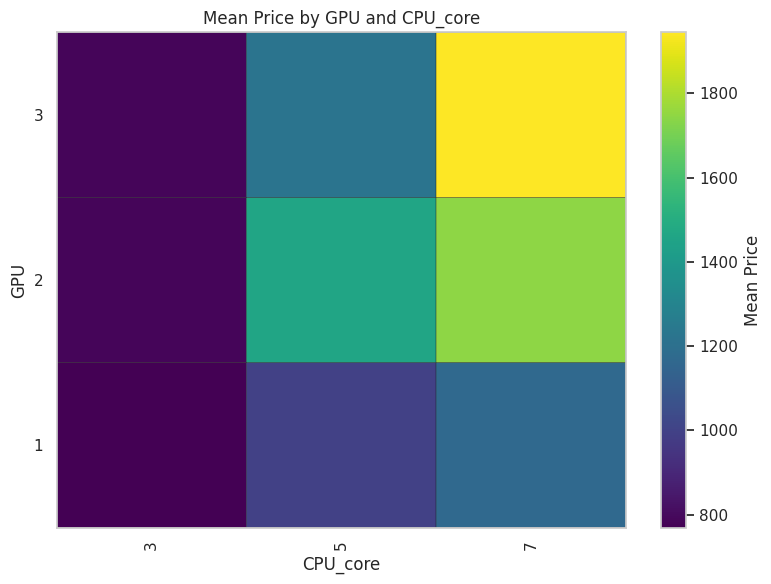

In [11]:
# Ensure required columns exist
required_cols = ['GPU', 'CPU_core', 'Price']
if not all(col in df.columns for col in required_cols):
    missing = [col for col in required_cols if col not in df.columns]
    raise ValueError(f"Missing required columns in df: {missing}")

# 1 & 2: Pivot table with mean of Price, grouped by GPU and CPU_core
pivot = df.pivot_table(index='GPU', columns='CPU_core', values='Price', aggfunc='mean')

# (Optional) sort for nicer plotting
pivot = pivot.sort_index()
pivot = pivot.reindex(columns=sorted(pivot.columns))

# Replace NaNs (no data for some combos) to enable plotting
plot_data = pivot.values
plot_data = np.where(np.isnan(plot_data), 0, plot_data)

# 3: pcolor plot
plt.figure(figsize=(8, 6))
c = plt.pcolor(plot_data, cmap='viridis', edgecolors='k', shading='auto')
plt.colorbar(c, label='Mean Price')

# Axes labels and ticks
plt.xlabel('CPU_core')
plt.ylabel('GPU')
plt.xticks(np.arange(0.5, plot_data.shape[1], 1), pivot.columns, rotation=90)
plt.yticks(np.arange(0.5, plot_data.shape[0], 1), pivot.index)

plt.title('Mean Price by GPU and CPU_core')
plt.tight_layout()
plt.show()

## Authors


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
